<a href="https://colab.research.google.com/github/vappanna/Final_Project/blob/main/RandomForest_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. DATA PREP & MULTI-MODEL VALIDATION ---


/tmp/ipykernel_4504/773583647.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  last_known.at[idx, val_c] = mean_p


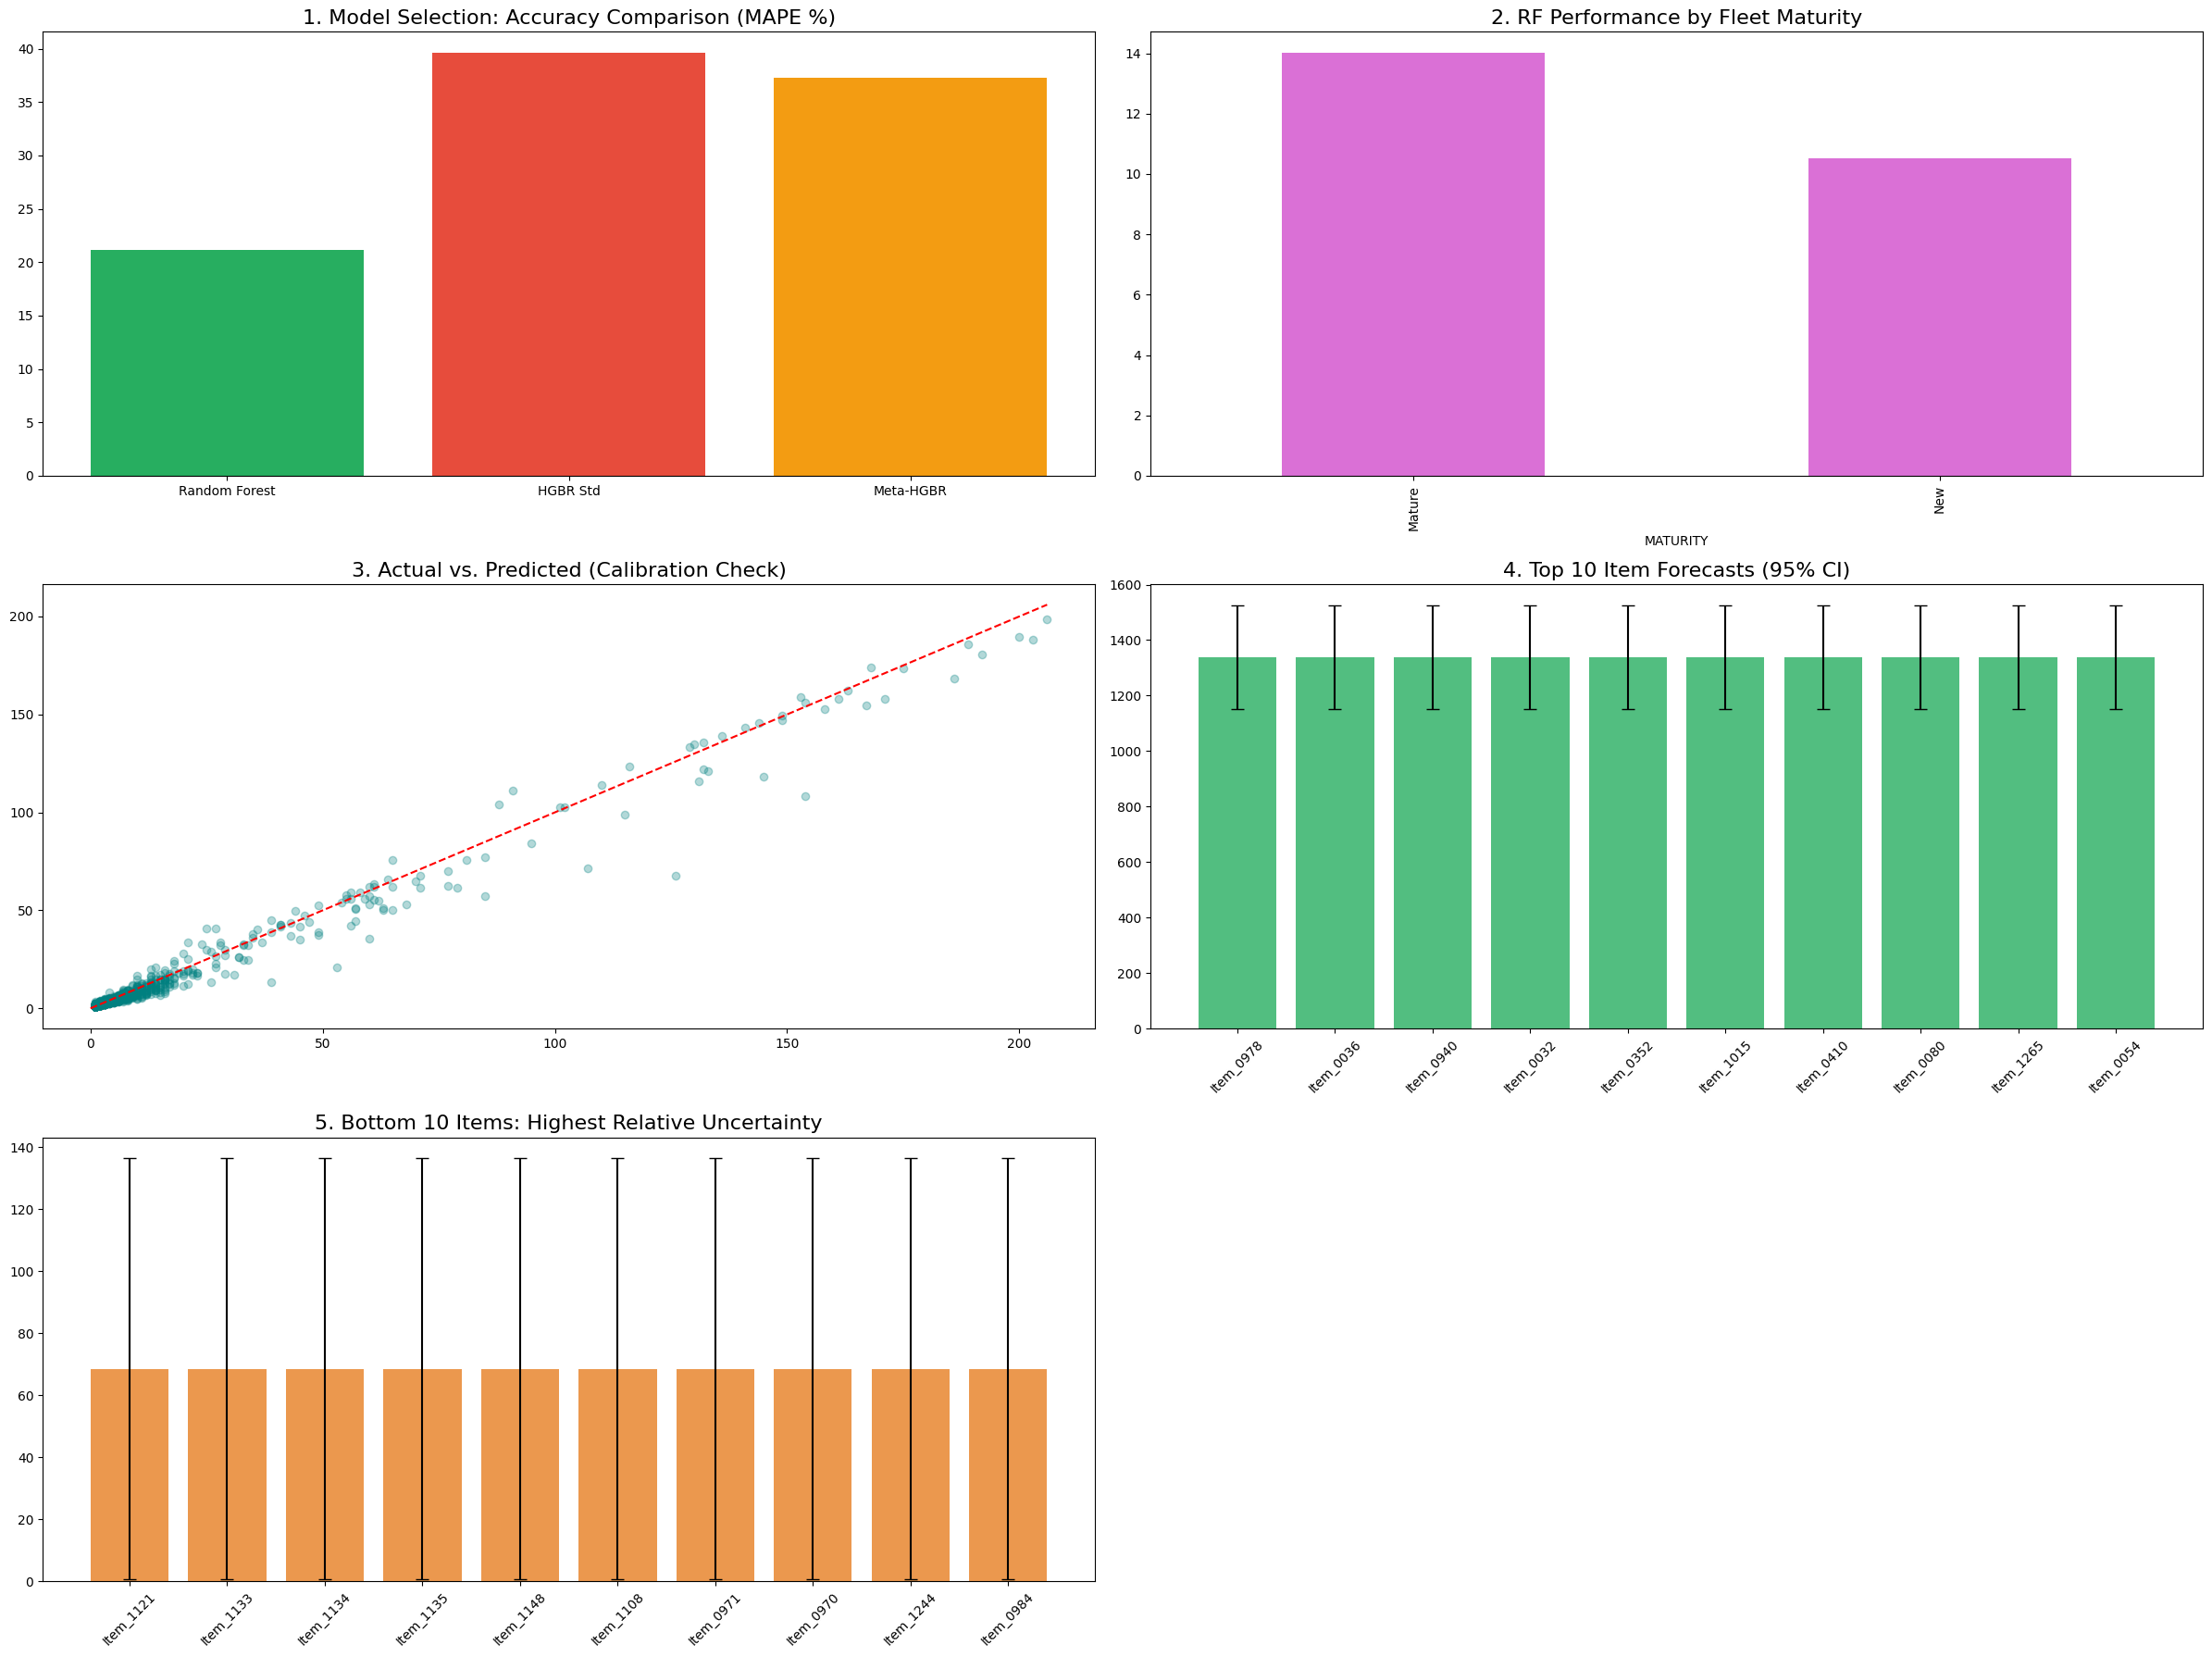


✅ All charts including 3-Model Comparison generated successfully.
Winning Model: Random Forest (21.13% MAPE)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_percentage_error

def run_full_spectrum_master_suite():
    print("--- 1. DATA PREP & MULTI-MODEL VALIDATION ---")
    all_files = os.listdir('/content/')
    def find_file(keyword):
        for f in all_files:
            if keyword.lower() in f.lower() and f.endswith('.csv'):
                return os.path.join('/content/', f)
        return None

    data_path = find_file('install') or find_file('fleet')
    item_path = find_file('item')
    if not data_path or not item_path: return print("❌ Error: CSVs missing.")

    df_f = pd.read_csv(data_path, encoding='latin1')
    df_f.columns = [str(c).strip().upper() for c in df_f.columns]
    reg_c = next(c for c in df_f.columns if 'REGION' in c)
    mach_c = next(c for c in df_f.columns if 'MACHINE' in c or 'MODEL' in c)
    val_c = next(c for c in df_f.columns if 'FLEET' in c or 'INSTALL' in c)

    # Engineering Features
    df_f['VOLATILITY_CV'] = df_f.groupby([reg_c, mach_c])[val_c].transform(lambda x: (x.std() / x.mean() * 100)).fillna(0)
    df_f['YEAR'] = pd.to_numeric(df_f['QUARTER'].astype(str).str[:4], errors='coerce')
    df_f['Q'] = pd.to_numeric(df_f['QUARTER'].astype(str).str[-1:], errors='coerce')
    df_f['MATURITY'] = np.where(df_f.groupby([reg_c, mach_c])[val_c].transform('count') >= 8, 'Mature', 'New')
    df_f = df_f.sort_values([reg_c, mach_c, 'YEAR', 'Q'])
    df_f['LAG_1'] = df_f.groupby([reg_c, mach_c])[val_c].shift(1)
    df_f['ROLL_3'] = df_f.groupby([reg_c, mach_c])[val_c].transform(lambda x: x.rolling(3).mean().shift(1))
    df_clean = df_f.dropna(subset=['LAG_1', 'ROLL_3']).copy()

    # Pre-Processing
    base_feats = ['YEAR', 'Q', 'LAG_1', 'ROLL_3', reg_c, mach_c]
    meta_feats = base_feats + ['VOLATILITY_CV', 'MATURITY']
    enc_base = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit(df_clean[[reg_c, mach_c]])
    enc_meta = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit(df_clean[[reg_c, mach_c, 'MATURITY']])

    y = np.log1p(df_clean[val_c])
    X_base = df_clean[base_feats].copy(); X_base[[reg_c, mach_c]] = enc_base.transform(X_base[[reg_c, mach_c]])
    X_meta = df_clean[meta_feats].copy(); X_meta[[reg_c, mach_c, 'MATURITY']] = enc_meta.transform(X_meta[[reg_c, mach_c, 'MATURITY']])

    # 1. Comparison Metrics
    m_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_base, y)
    m_hg = HistGradientBoostingRegressor(random_state=42).fit(X_base, y)
    m_mt = HistGradientBoostingRegressor(random_state=42).fit(X_meta, y)

    mape_rf = mean_absolute_percentage_error(df_clean[val_c], np.expm1(m_rf.predict(X_base))) * 100
    mape_hg = mean_absolute_percentage_error(df_clean[val_c], np.expm1(m_hg.predict(X_base))) * 100
    mape_mt = mean_absolute_percentage_error(df_clean[val_c], np.expm1(m_mt.predict(X_meta))) * 100

    # 2. Uncertainty-Aware Forecasts (RF)
    last_known = df_clean.groupby([reg_c, mach_c]).last().reset_index()
    res = []
    for q in [1,2,3,4]:
        for idx, row in last_known.iterrows():
            d = {f: row[f] for f in base_feats if f not in ['YEAR', 'Q', 'LAG_1']}
            d.update({'YEAR': 2027, 'Q': q, 'LAG_1': row[val_c]})
            X_in = pd.DataFrame([d])[base_feats]; X_in[[reg_c, mach_c]] = enc_base.transform(X_in[[reg_c, mach_c]])
            tree_preds = [np.expm1(t.predict(X_in.values))[0] for t in m_rf.estimators_]
            mean_p = np.mean(tree_preds)
            res.append({mach_c: row[mach_c], 'P': mean_p, 'ERR': 1.96 * np.std(tree_preds)})
            last_known.at[idx, val_c] = mean_p

    # Aggregating to Items
    f_res = pd.DataFrame(res).groupby(mach_c).agg({'P':'sum', 'ERR': lambda x: np.sqrt(np.sum(x**2))}).reset_index()
    df_i = pd.read_csv(item_path, encoding='latin1'); df_i.columns = [str(c).strip().upper() for c in df_i.columns]
    itm_map = df_i.groupby(next(c for c in df_i.columns if 'MACHINE' in c or 'MODEL' in c))[next(c for c in df_i.columns if 'ITEM' in c)].unique().to_dict()

    rows = []
    for _, r in f_res.iterrows():
        if r[mach_c] in itm_map:
            for itm in itm_map[r[mach_c]]: rows.append({'ITEM': itm, 'PROJ': r['P'], 'CONF_ERR': r['ERR']})

    final_output = pd.DataFrame(rows).groupby('ITEM').agg({'PROJ':'sum', 'CONF_ERR': lambda x: np.sqrt(np.sum(x**2))}).reset_index()
    final_output['REL_ERROR'] = (final_output['CONF_ERR'] / (final_output['PROJ'] + 1)) * 100

    # --- FINAL 5-CHART DASHBOARD ---
    plt.figure(figsize=(24, 18))

    # Chart 1: The Model Comparison (Restored)
    plt.subplot(3, 2, 1)
    plt.bar(['Random Forest', 'HGBR Std', 'Meta-HGBR'], [mape_rf, mape_hg, mape_mt], color=['#27ae60', '#e74c3c', '#f39c12'])
    plt.title('1. Model Selection: Accuracy Comparison (MAPE %)', fontsize=16)

    # Chart 2: Maturity Analysis
    plt.subplot(3, 2, 2)
    df_clean['MAPE_RF'] = (abs(df_clean[val_c] - np.expm1(m_rf.predict(X_base))) / (df_clean[val_c] + 1)) * 100
    df_clean.groupby('MATURITY')['MAPE_RF'].mean().plot(kind='bar', color='orchid')
    plt.title('2. RF Performance by Fleet Maturity', fontsize=16)

    # Chart 3: Calibration Scatter
    plt.subplot(3, 2, 3)
    plt.scatter(df_clean[val_c], np.expm1(m_rf.predict(X_base)), alpha=0.3, color='teal')
    plt.plot([0, df_clean[val_c].max()], [0, df_clean[val_c].max()], '--', color='red')
    plt.title('3. Actual vs. Predicted (Calibration Check)', fontsize=16)

    # Chart 4: Top 10 High Volume (95% CI)
    plt.subplot(3, 2, 4)
    top_10 = final_output.sort_values('PROJ', ascending=False).head(10)
    plt.bar(top_10['ITEM'], top_10['PROJ'], yerr=top_10['CONF_ERR'], capsize=5, color='#27ae60', alpha=0.8)
    plt.xticks(rotation=45); plt.title('4. Top 10 Item Forecasts (95% CI)', fontsize=16)

    # Chart 5: Bottom 10 High Risk (Uncertainty)
    plt.subplot(3, 2, 5)
    bottom_10 = final_output.sort_values('REL_ERROR', ascending=False).head(10)
    plt.bar(bottom_10['ITEM'], bottom_10['PROJ'], yerr=bottom_10['CONF_ERR'], capsize=5, color='#e67e22', alpha=0.8)
    plt.xticks(rotation=45); plt.title('5. Bottom 10 Items: Highest Relative Uncertainty', fontsize=16)

    plt.tight_layout(); plt.savefig('/content/MASTER_FORECAST_DASHBOARD.png'); plt.show()
    print(f"\n✅ All charts including 3-Model Comparison generated successfully.\nWinning Model: Random Forest ({mape_rf:.2f}% MAPE)")

run_full_spectrum_master_suite()